# Лабораторная работа №4

Решить задачу классификации датасета MNIST используя MLP из scikitlearn и используя CNN (по типу LeNet) c пакетом PyTorch. Сравнить результаты по метрикам, сделать обоснованные выводы.

In [38]:
# Библиотеки

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time


from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

Рассмотрим датасет

In [ ]:
mnist = fetch_openml('mnist_784', version=1, parser='auto')
X, y = mnist.data, mnist.target

# Преобразование меток в целые числа
y = y.astype(int)

print(f"Полный набор данных: {X.shape[0]} изображений, {X.shape[1]} признаков (пикселей)")
print(f"Метки (цифры от 0 до 9): {np.unique(y)}")


Полный набор данных: 70000 изображений, 784 признаков (пикселей)
Метки (цифры от 0 до 9): [0 1 2 3 4 5 6 7 8 9]


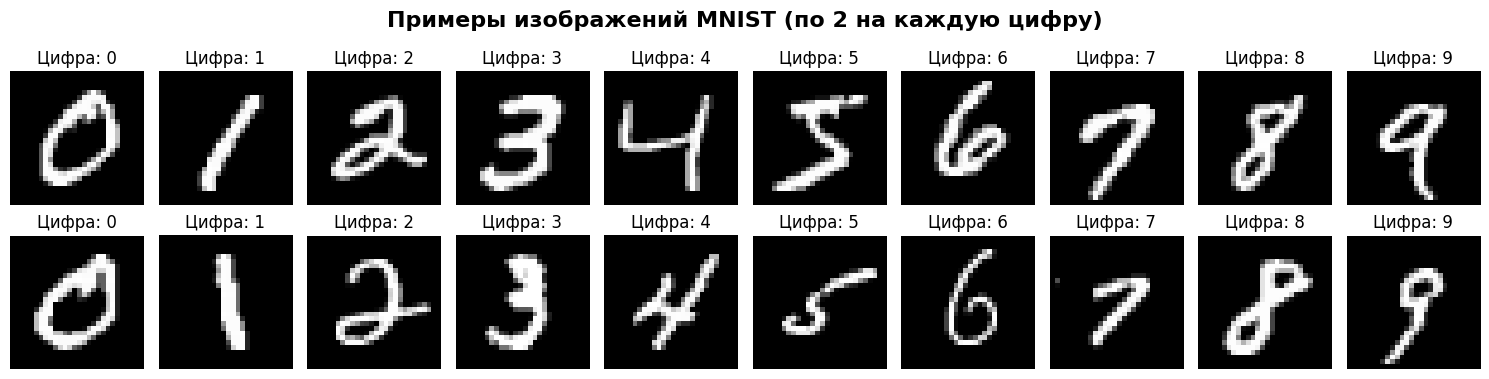

In [18]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
fig.suptitle('Примеры изображений MNIST (по 2 на каждую цифру)', fontsize=16, fontweight='bold')

for digit in range(10):
    indices = np.where(y == digit)[0]
    for i in range(2):
        idx = indices[i]
        img = X.iloc[idx].values.reshape(28, 28) if hasattr(X, 'iloc') else X[idx].reshape(28, 28)
        
        ax = axes[i, digit]
        ax.imshow(img, cmap='gray')
        ax.set_title(f'Цифра: {digit}')
        ax.axis('off')

plt.tight_layout()

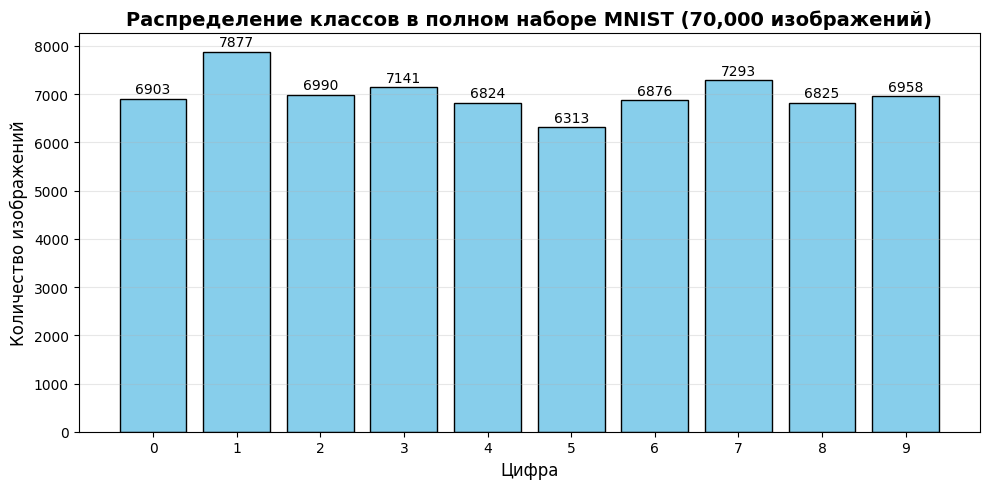

In [20]:
plt.figure(figsize=(10, 5))

unique, counts = np.unique(y, return_counts=True)
bars = plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.xlabel('Цифра', fontsize=12)
plt.ylabel('Количество изображений', fontsize=12)
plt.title('Распределение классов в полном наборе MNIST (70,000 изображений)', fontsize=14, fontweight='bold')
plt.xticks(unique)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count}', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

In [ ]:
# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=10000, train_size=60000, random_state=42, shuffle=True
)

# Нормализация данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(float))
X_test_scaled = scaler.transform(X_test.astype(float))
print(f"Размеры данных: Train {X_train_scaled.shape}, Test {X_test_scaled.shape}")

Теперь рассмотрим MLP из scikitlearn.

In [47]:
mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64), # три слоя нейронов (1 слой: 256 нейорнов, 2 слой: 128 нейронов, 3 слой: 64 слоя)
    activation='logistic', # функция активации, применяемая к выводу увждого нейрона
    solver='adam', # алгоритм отимизации, используемый для обновления весов сети
    alpha=0.0001, # коэффициент L2-регуляризация
    batch_size=256,
    learning_rate='adaptive', # стратегия адаптации скорости обучения
    learning_rate_init=0.001, 
    max_iter=50,
    random_state=42,
    verbose=True,
    early_stopping=True, # включение ранней остановки
    validation_fraction=0.1 # доля данных для валидации от трейн
)

start_time = time.time()
mlp.fit(X_train_scaled, y_train) # обучение модели
mlp_time = time.time() - start_time

# Предсказания
y_pred = mlp.predict(X_test_scaled)
y_pred_proba = mlp.predict_proba(X_test_scaled)


Iteration 1, loss = 1.20839142
Validation score: 0.895000
Iteration 2, loss = 0.33757255
Validation score: 0.932500
Iteration 3, loss = 0.20346737
Validation score: 0.947500
Iteration 4, loss = 0.14154037
Validation score: 0.953833
Iteration 5, loss = 0.10426764
Validation score: 0.959667
Iteration 6, loss = 0.07681490
Validation score: 0.962500
Iteration 7, loss = 0.05758550
Validation score: 0.964167
Iteration 8, loss = 0.04202836
Validation score: 0.965000
Iteration 9, loss = 0.03062388
Validation score: 0.964833
Iteration 10, loss = 0.02233896
Validation score: 0.967333
Iteration 11, loss = 0.01570262
Validation score: 0.968833
Iteration 12, loss = 0.01140341
Validation score: 0.968500
Iteration 13, loss = 0.00844149
Validation score: 0.969500
Iteration 14, loss = 0.00622731
Validation score: 0.969667
Iteration 15, loss = 0.00452071
Validation score: 0.969333
Iteration 16, loss = 0.00347339
Validation score: 0.967000
Iteration 17, loss = 0.00283341
Validation score: 0.969167
Iterat

In [50]:
print(f"Время обучения: {mlp_time:.1f} сек")

report_dict = classification_report(y_test, y_pred, output_dict=True, digits=4)

print(f"\nОбщие метрики модели:")
print(f"  Точность (accuracy):          {accuracy:.4%}")
print(f"  Macro avg precision:          {report_dict['macro avg']['precision']:.4%}")
print(f"  Macro avg recall:             {report_dict['macro avg']['recall']:.4%}")
print(f"  Macro avg f1-score:           {report_dict['macro avg']['f1-score']:.4%}")
print(f"  Weighted avg f1-score:        {report_dict['weighted avg']['f1-score']:.4%}")

Время обучения: 148.3 сек

Общие метрики модели:
  Точность (accuracy):          99.1000%
  Macro avg precision:          96.8507%
  Macro avg recall:             96.8545%
  Macro avg f1-score:           96.8491%
  Weighted avg f1-score:        96.8668%


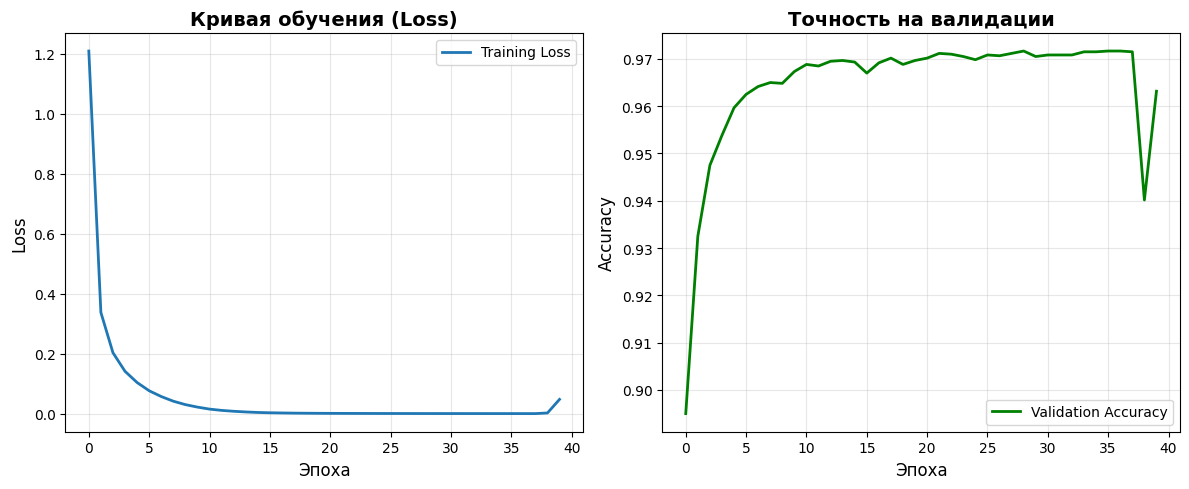

In [51]:
plt.figure(figsize=(12, 5))

# График функции потерь
plt.subplot(1, 2, 1)
plt.plot(mlp.loss_curve_, label='Training Loss', linewidth=2)
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Кривая обучения (Loss)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()

# График точности на валидации (если доступен)
plt.subplot(1, 2, 2)
if hasattr(mlp, 'validation_scores_'):
    plt.plot(mlp.validation_scores_, label='Validation Accuracy', linewidth=2, color='green')
    plt.xlabel('Эпоха', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Точность на валидации', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()

Расмотрим CNN с пакетом PyTorch. Сделаем LeNet-5 архитектуру.

In [42]:
class MyLeNet5(nn.Module):
    def __init__(self):
        super(MyLeNet5, self).__init__()
        # Сверточные слои
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=2)  # 28x28 -> 28x28  
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)      # 28x28 -> 14x14
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)            # 14x14 -> 10x10
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)      # 10x10 -> 5x5
        
        # Полносвязные слои
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
        # Dropout для регуляризации
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))
        x = self.pool2(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)  # Flatten
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Загрузка и подготовка данных MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Загрузка данных
train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# Создание DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False, num_workers=2)

# Инициализация модели, функции потерь и оптимизатора
model = MyLeNet5()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

num_epochs = 20
train_losses = []
test_accuracies = []

start_time = time.time()
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data, target
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    train_losses.append(running_loss / len(train_loader))
    
    # Оценка на тестовых данных
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data, target
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = correct / total
    test_accuracies.append(accuracy)
    
    print(f'Epoch {epoch+1}/{num_epochs}, Loss: {train_losses[-1]:.4f}, Accuracy: {accuracy:.4f}')
    
    scheduler.step()

cnn_time = time.time() - start_time

Epoch 1/20, Loss: 0.4987, Accuracy: 0.9671
Epoch 2/20, Loss: 0.1747, Accuracy: 0.9807
Epoch 3/20, Loss: 0.1315, Accuracy: 0.9847
Epoch 4/20, Loss: 0.1078, Accuracy: 0.9839
Epoch 5/20, Loss: 0.0921, Accuracy: 0.9856
Epoch 6/20, Loss: 0.0851, Accuracy: 0.9881
Epoch 7/20, Loss: 0.0751, Accuracy: 0.9888
Epoch 8/20, Loss: 0.0702, Accuracy: 0.9897
Epoch 9/20, Loss: 0.0632, Accuracy: 0.9906
Epoch 10/20, Loss: 0.0593, Accuracy: 0.9902
Epoch 11/20, Loss: 0.0459, Accuracy: 0.9908
Epoch 12/20, Loss: 0.0454, Accuracy: 0.9915
Epoch 13/20, Loss: 0.0420, Accuracy: 0.9917
Epoch 14/20, Loss: 0.0396, Accuracy: 0.9929
Epoch 15/20, Loss: 0.0366, Accuracy: 0.9920
Epoch 16/20, Loss: 0.0375, Accuracy: 0.9911
Epoch 17/20, Loss: 0.0328, Accuracy: 0.9912
Epoch 18/20, Loss: 0.0342, Accuracy: 0.9913
Epoch 19/20, Loss: 0.0330, Accuracy: 0.9917
Epoch 20/20, Loss: 0.0309, Accuracy: 0.9910


In [56]:
print(f"Время обучения: {cnn_time:.1f} сек")
# Получаем все предсказания для тестового набора
all_predictions = []
all_targets = []

model.eval()
with torch.no_grad():
    for data, target in test_loader:
        data, target = data, target
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        all_predictions.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

report = classification_report(all_targets, all_predictions, 
                              output_dict=True,  digits=4)
print(f"\nОбщие метрики модели:")
print(f"  Точность (accuracy):          {accuracy:.4%}")
print(f"  Macro avg precision:          {report['macro avg']['precision']:.4%}")
print(f"  Macro avg recall:             {report['macro avg']['recall']:.4%}")
print(f"  Macro avg f1-score:           {report['macro avg']['f1-score']:.4%}")
print(f"  Weighted avg f1-score:        {report['weighted avg']['f1-score']:.4%}")

Время обучения: 516.2 сек

Общие метрики модели:
  Точность (accuracy):          99.1000%
  Macro avg precision:          99.1030%
  Macro avg recall:             99.0958%
  Macro avg f1-score:           99.0983%
  Weighted avg f1-score:        99.0997%


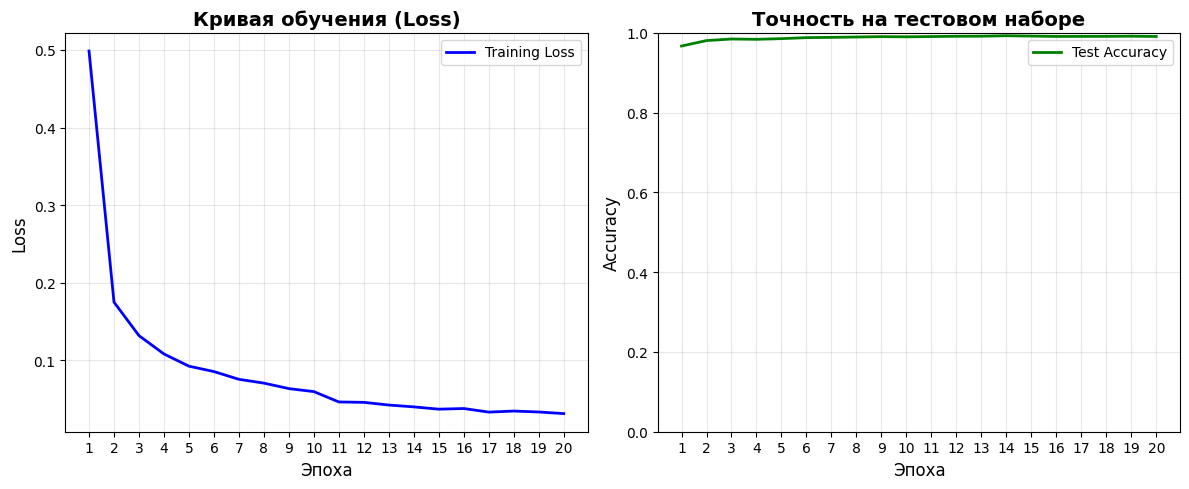

In [ ]:
plt.figure(figsize=(12, 5))

# График функции потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Training Loss', linewidth=2, color='blue')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Кривая обучения (Loss)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(range(1, len(train_losses) + 1))

# График точности на тестовом наборе 
plt.subplot(1, 2, 2)
plt.plot(range(1, len(test_accuracies) + 1), test_accuracies, label='Test Accuracy', linewidth=2, color='green')
plt.xlabel('Эпоха', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Точность на тестовом наборе', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(range(1, len(test_accuracies) + 1)) 
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### Вывод

**Качество классификации**<br>
Точность у обеих моделей одинаковая — 99.1%. Однако средние метрики (macro avg) существенно различаются:
* MLP: macro F1 ≈ 96.85%
* CNN (LeNet-5): macro F1 ≈ 99.10%
Это означает, что MLP хуже справляется с отдельными классами. А CNN демонстрирует более сбалансированное качество по всем классам, что особенно важно при неравномерном распределении данных.

**Обучение и сходимость**<br>
MLP (40 итераций):
* Очень быстрое снижение loss практически до нуля.
* Высокая точность, но заметен риск переобучения, что косвенно подтверждается более низкими macro-метриками.

CNN (20 итераций):
* Плавное и стабильное снижение loss.
* Высокая и устойчивая точность на тестовом наборе.

**Время обучения**<br>
MLP: 148.3 сек
CNN: 516.2 сек
MLP обучается быстрее, что делает его выгодным при ограниченных вычислительных ресурсах или необходимости быстрого прототипирования.

Т.о. 
MLP - хороший и быстрый базовый вариант, подходящий для простых задач и ограниченных ресурсов.
CNN (LeNet-5) - предпочтительная модель для задач компьютерного зрения, так как при одинаковой accuracy она обеспечивает более высокое и равномерное качество по классам, пусть и ценой большего времени обучения.